This is for learning to generate plots

Parsing files and cleaning data...
Data combined! Generating plot...


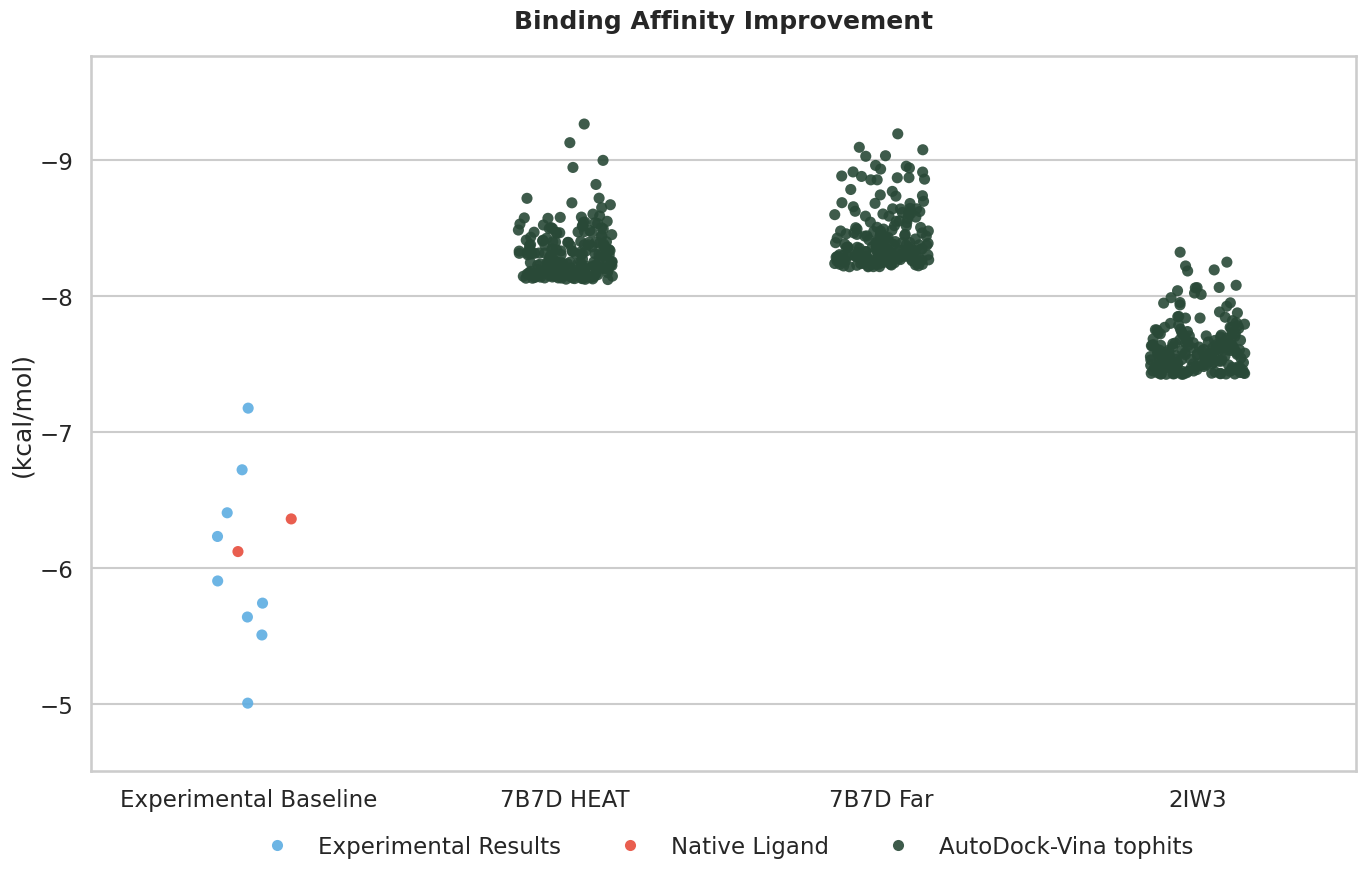

Graph saved successfully.


In [9]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("Parsing files and cleaning data...")

# ==========================================
# STEP 1: Parse Experimental Results
# ==========================================
exp_df = pd.read_csv('experimental_results.txt', sep=r'\s+', header=None, names=['molecule', 'score'])
exp_df['molecule'] = exp_df['molecule'].str.replace('_results.log', '', regex=False)
exp_df['molecule'] = exp_df['molecule'].str.replace('tophit_high_', '', regex=False)
exp_df['molecule'] = exp_df['molecule'].str.replace('tophit_low_', '', regex=False)

def categorize_exp(name):
    if 'ATP' in name or 'ADP' in name:
        return 'Native Ligand'
    else:
        return 'Experimental Results'

exp_df['Category'] = exp_df['molecule'].apply(categorize_exp)
exp_df['Pocket'] = 'Experimental Baseline'

# ==========================================
# STEP 2: Parse Vina HTVS - Top 200 Pockets
# ==========================================
# Note: If you generated the top_500 files, just change the filenames here!
heat_df = pd.read_csv('7B7D_HEAT_top200.txt', sep=r'\s+', header=None, names=['molecule', 'score'])
heat_df['Category'] = 'AutoDock-Vina tophits'
heat_df['Pocket'] = '7B7D HEAT'

far_df = pd.read_csv('7B7D_far_top200.txt', sep=r'\s+', header=None, names=['molecule', 'score'])
far_df['Category'] = 'AutoDock-Vina tophits'
far_df['Pocket'] = '7B7D Far'

iw3_df = pd.read_csv('2IW3_top200.txt', sep=r'\s+', header=None, names=['molecule', 'score'])
iw3_df['Category'] = 'AutoDock-Vina tophits'
iw3_df['Pocket'] = '2IW3'

# ==========================================
# STEP 3: Combine and Export
# ==========================================
df = pd.concat([exp_df, heat_df, far_df, iw3_df], ignore_index=True)
df.to_csv('YeF3_allpockets_top200_results.csv', index=False)

print("Data combined! Generating plot...")

# ==========================================
# STEP 4: Setup Plot Canvas & Palette
# ==========================================
plt.figure(figsize=(14, 10))
sns.set_theme(style="whitegrid", context="talk")

palette = {
    'Experimental Results': '#5DADE2',        
    'Native Ligand': '#e74c3c', 
    'AutoDock-Vina tophits': "#294937"          
}

pockets = list(df['Pocket'].dropna().unique())

# ==========================================
# STEP 5: Draw Stripplot
# ==========================================
ax = sns.stripplot(
    data=df,
    x='Pocket',       
    y='score',        
    hue='Category',   
    palette=palette,
    size=8,             # Size of the markers
    alpha=0.9,          # Adds slight transparency to see overlapping density
    jitter=0.15,        # Adds horizontal noise to spread the points out
    order=pockets,
    hue_order=list(palette.keys())
)

# ==========================================
# STEP 6: Final Formatting
# ==========================================
# Invert Y-axis
bottom_limit = df['score'].max() + 0.5
top_limit = df['score'].min() - 0.5
ax.set_ylim(bottom_limit, top_limit)

ax.set_xlabel('')
ax.set_ylabel('(kcal/mol)')
ax.set_title('Binding Affinity Improvement', pad=20, weight='bold')

# Legend formatting
sns.move_legend(ax, "lower center", bbox_to_anchor=(0.5, -0.15), ncol=3, title=None, frameon=False)

plt.tight_layout(rect=[0, 0.08, 1, 1])
plt.savefig("YeF3_AllPockets_stripplot_top200.png", format="png", bbox_inches="tight", dpi=300)
plt.show()

print("Graph saved successfully.")
